# Online range evaluation (artifact CSV)

Loads **combo-range probabilities** from `artifacts/online_range_history.csv` (see `runner.py session-split` / ``--range-csv-out``). Joins each row to the Pluribus ``.phh`` via `(session, hand_number)` to attach **cumulative board**, **target hole cards**, and **p1–p6** seats.

**Brier**: preflop rows use 1,326 → **169** collapse; postflop rows use full **1,326** keys. **Expected strength** uses Monte Carlo under the row distribution (faster than enumerating all combos); set `STRENGTH_MC_SAMPLES` or a row cap while iterating.

Run from the repo root with the project virtualenv (`.venv`) as the kernel.


In [26]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

REPO = Path.cwd().resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from utils.eval.online_csv import (
    add_calibration_columns,
    combo_probability_columns,
    enrich_online_range_dataframe,
)


In [27]:
# --- configure ---
CSV_PATH = REPO / "artifacts" / "filter_sessions_range_history.csv"
PLURIBUS_ROOT = REPO / "pluribus"
STRENGTH_MC_SAMPLES = 100
RNG_SEED = 0
VERBOSE = True  # stdout progress from enrich + calibration
PROGRESS_EVERY_ENRICH = 100
PROGRESS_EVERY_CALIB = 50
# set to None for all rows (664 rows × MC may take a few minutes)
MAX_ROWS: int | None = None


In [28]:
df_raw = pd.read_csv(CSV_PATH)
combo_cols = combo_probability_columns(df_raw)
if MAX_ROWS is not None:
    df_raw = df_raw.iloc[: MAX_ROWS].copy()

df = enrich_online_range_dataframe(
    df_raw,
    PLURIBUS_ROOT,
    verbose=VERBOSE,
    progress_every=PROGRESS_EVERY_ENRICH,
)
rng = np.random.default_rng(RNG_SEED)
df = add_calibration_columns(
    df,
    combo_cols,
    strength_mc_samples=STRENGTH_MC_SAMPLES,
    strength_rng=rng,
    verbose=VERBOSE,
    progress_every=PROGRESS_EVERY_CALIB,
)
df


/var/folders/38/nnmd9r6n6_14yltphkbwq2nm0000gn/T/ipykernel_6604/1289185805.py:1: DtypeWarning: Columns (0: session) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(CSV_PATH)


[eval] enrich_online_range_dataframe: 13846 rows | pluribus_root=/Users/kevinliu/Desktop/bayesian poker/pluribus
[eval] enrich … row 1/13846
[eval] enrich … row 100/13846
[eval] enrich … row 200/13846
[eval] enrich … row 300/13846
[eval] enrich … row 400/13846
[eval] enrich … row 500/13846
[eval] enrich … row 600/13846
[eval] enrich … row 700/13846
[eval] enrich … row 800/13846
[eval] enrich … row 900/13846
[eval] enrich … row 1000/13846
[eval] enrich … row 1100/13846
[eval] enrich … row 1200/13846
[eval] enrich … row 1300/13846
[eval] enrich … row 1400/13846
[eval] enrich … row 1500/13846
[eval] enrich … row 1600/13846
[eval] enrich … row 1700/13846
[eval] enrich … row 1800/13846
[eval] enrich … row 1900/13846
[eval] enrich … row 2000/13846
[eval] enrich … row 2100/13846
[eval] enrich … row 2200/13846
[eval] enrich … row 2300/13846
[eval] enrich … row 2400/13846
[eval] enrich … row 2500/13846
[eval] enrich … row 2600/13846
[eval] enrich … row 2700/13846
[eval] enrich … row 2800/13846


,session,hand_number,street,observer,target,3s2s,4s2s,5s2s,6s2s,7s2s,...,p2,p3,p4,p5,p6,brier,expected_made_pct,expected_draw,actual_made_pct,actual_draw
0,40b,121,pre-flop,MrBlue,Bill,0.000828,0.000836,0.000845,0.000855,0.000862,...,MrBlue,Bill,MrOrange,Pluribus,ORen,0.993586,NaN,NaN,NaN,NaN
1,40b,121,flop,MrBlue,Bill,0.000828,0.000836,0.001127,0.000855,0.000862,...,MrBlue,Bill,MrOrange,Pluribus,ORen,0.999423,0.591804,0.000000,0.681314,0.0
2,40b,121,turn,MrBlue,Bill,0.000831,0.000839,0.001130,0.000858,0.000865,...,MrBlue,Bill,MrOrange,Pluribus,ORen,0.999665,0.582300,0.000000,0.711594,0.0
3,40b,121,river,MrBlue,Bill,0.000000,0.000839,0.001130,0.000858,0.000865,...,MrBlue,Bill,MrOrange,Pluribus,ORen,0.999734,0.664338,0.000000,0.590404,0.0
4,40b,121,pre-flop,Bill,MrBlue,0.000914,0.000896,0.000877,0.000856,0.000839,...,MrBlue,Bill,MrOrange,Pluribus,ORen,0.992547,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13841,95b,165,river,Bill,Pluribus,0.000826,0.000833,0.001261,0.000850,0.000855,...,Eddie,Pluribus,Bill,MrOrange,MrBlue,0.998503,0.544641,0.000000,0.594949,0.0
13842,95b,165,pre-flop,Pluribus,Bill,0.000829,0.000837,0.000847,0.000857,0.000000,...,Eddie,Pluribus,Bill,MrOrange,MrBlue,1.003109,NaN,NaN,NaN,NaN
13843,95b,165,flop,Pluribus,Bill,0.000829,0.000837,0.000847,0.000857,0.000000,...,Eddie,Pluribus,Bill,MrOrange,MrBlue,0.999363,0.574376,0.044091,0.326087,0.0
13844,95b,165,turn,Pluribus,Bill,0.000829,0.000837,0.001270,0.000857,0.000000,...,Eddie,Pluribus,Bill,MrOrange,MrBlue,0.998624,0.548744,0.035455,0.592271,0.0


In [29]:
df.to_csv(REPO / "artifacts" / "filter_sessions_range_history_enriched.csv", index=False)

In [5]:
display(df.groupby("street", sort=False)["brier"].agg(["mean", "count"]))

post = df[df["community_cards"].str.len() >= 6]
display(
    post.groupby("street", sort=False)[
        ["expected_made_pct", "actual_made_pct", "expected_draw", "actual_draw"]
    ].mean(numeric_only=True)
)


,mean,count
street,,
pre-flop,0.990816,299
flop,0.998776,168
turn,0.998702,118
river,0.998704,78


,expected_made_pct,actual_made_pct,expected_draw,actual_draw
street,,,,
flop,0.540560,0.554428,0.070473,0.072240
turn,0.545952,0.557373,0.058861,0.053544
river,0.542636,0.511765,0.000000,0.000000


In [6]:
# find mse, mean absolute error between expected and actual made percentile and draw and display
for street in ["flop", "turn", "river"]:
    subset = df[df["street"] == street]
    mse_made = np.mean((subset["expected_made_pct"] - subset["actual_made_pct"]) ** 2)
    mae_made = np.mean(np.abs(subset["expected_made_pct"] - subset["actual_made_pct"]))
    mse_draw = np.mean((subset["expected_draw"] - subset["actual_draw"]) ** 2)
    mae_draw = np.mean(np.abs(subset["expected_draw"] - subset["actual_draw"]))
    print(
        f"{street.capitalize()}: Made Percentile MSE={mse_made:.4f}, MAE={mae_made:.4f}; "
        f"Draw MSE={mse_draw:.4f}, MAE={mae_draw:.4f}"
    )

Flop: Made Percentile MSE=0.0850, MAE=0.2529; Draw MSE=0.0175, MAE=0.0910
Turn: Made Percentile MSE=0.0735, MAE=0.2303; Draw MSE=0.0160, MAE=0.0754
River: Made Percentile MSE=0.0752, MAE=0.2277; Draw MSE=0.0000, MAE=0.0000


In [ ]:
# Made-percentile distribution metrics (from `add_calibration_columns`)
# `actual_made_pct` uses the cached 1,326-vector path (`made_percentile_vector_1326`).
# To compare multiple predictors, concatenate exports with a `predictor` column and
# call `_plot_rank_ecdf` once per label.
import matplotlib.pyplot as plt


def _plot_rank_ecdf(curves: dict[str, np.ndarray], title: str) -> None:
    plt.figure(figsize=(9, 4))
    for label, vals in curves.items():
        v = np.asarray(vals, dtype=float)
        v = v[np.isfinite(v)]
        v.sort()
        if v.size == 0:
            continue
        v = np.clip(v, 0.0, 1.0)
        y = np.arange(1, len(v) + 1, dtype=float) / len(v)
        plt.step(v, y, where="post", label=label)
    plt.xlabel("value")
    plt.ylabel("ECDF over hands")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


post = df[df["street"] != "pre-flop"]
if not post.empty and "made_pct_z" in post.columns:
    for street in ["flop", "turn", "river"]:
        sub = post[post["street"] == street]
        zv = sub["made_pct_z"].to_numpy(dtype=float)
        mask = np.isfinite(zv)
        if not mask.any():
            continue
        print(
            f"{street.capitalize()}: mean z={np.mean(zv[mask]):.4f}, "
            f"mean |z|={np.nanmean(sub['made_pct_abs_z'].to_numpy()):.4f}, "
            f"mean NLL={np.nanmean(sub['combo_nll'].to_numpy()):.4f}"
        )
    pred = "combo export"
    _plot_rank_ecdf(
        {
            f"{pred}: midrank (P<X*)+0.5 tie": post["made_pct_midrank"].to_numpy(dtype=float),
            f"{pred}: P(made≤true)": post["made_pct_cdf_le"].to_numpy(dtype=float),
        },
        "ECDF of true-hand rank under each row's distribution",
    )
else:
    print("Postflop calibration columns missing; run add_calibration_columns first.")


In [8]:
import matplotlib.pyplot as plt

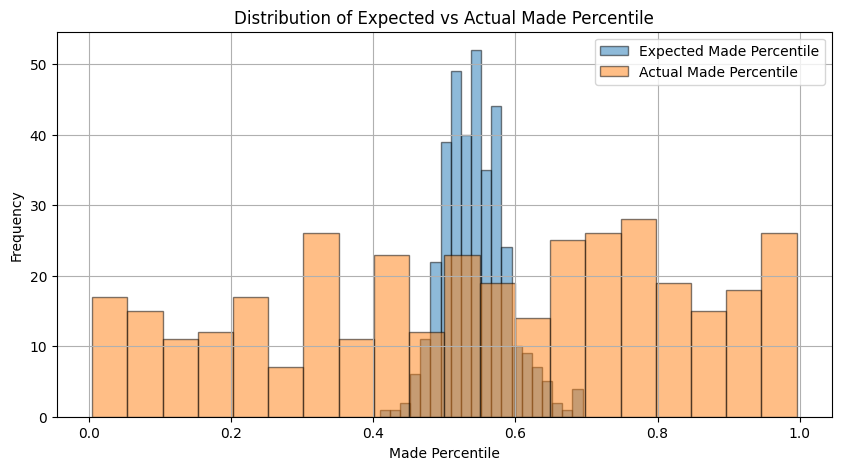

In [9]:
plt.figure(figsize=(10, 5))
plt.grid()
plt.hist(df['expected_made_pct'], bins=20, alpha=0.5, label='Expected Made Percentile', linewidth=1.0, edgecolor='black')
plt.hist(df['actual_made_pct'], bins=20, alpha=0.5, label='Actual Made Percentile', linewidth=1.0, edgecolor='black')
plt.legend()
plt.title('Distribution of Expected vs Actual Made Percentile')
plt.xlabel('Made Percentile')
plt.ylabel('Frequency')
plt.show()

In [13]:
import json

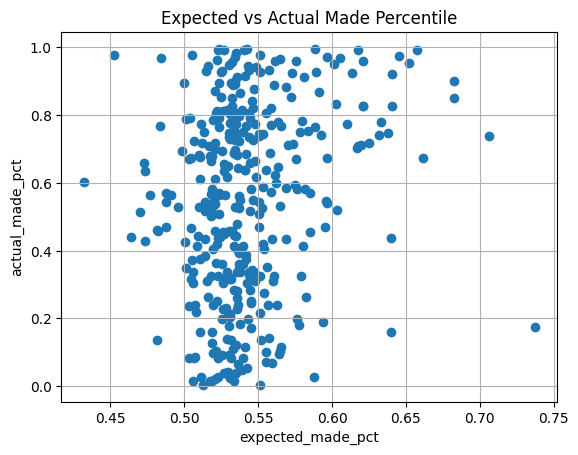

In [15]:
plt.scatter(df["expected_made_pct"], df["actual_made_pct"])
plt.xlabel("expected_made_pct")
plt.ylabel("actual_made_pct")
plt.title("Expected vs Actual Made Percentile")
plt.grid()
plt.show()

In [ ]:
from utils.eval.strength import (
    expected_made_mean_and_histogram_mode,
    plot_made_percentile_weighted_histogram,
)

In [ ]:


_post = df[(df["street"] != "pre-flop") & (df["community_cards"].str.len() >= 6)]
if _post.empty:
    print("No postflop rows in df; run enrichment cells first.")
else:
    _row = df.loc[_post.index[0]]
    _p = _row[combo_cols].to_numpy(dtype=float)
    _board = str(_row["community_cards"])
    _exp, _mode, _edges, _wts, _perc = expected_made_mean_and_histogram_mode(_p, _board)
    print(f"E[made]={_exp:.4f}  histogram_mode_bin_center={_mode:.4f}")
    if "expected_made_pct" in df.columns and pd.notna(_row.get("expected_made_pct")):
        print(f"expected_made_pct (MC calibration): {float(_row['expected_made_pct']):.4f}")
    plot_made_percentile_weighted_histogram(_p, _board, n_bins=40)
